# Preprocesamiento — Smoking Dataset

Pipeline completo: limpieza, encoding, feature engineering y scaling.
El output es `smoking_processed.csv` listo para modelado.



### Librerias

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from collections import Counter
import joblib

%matplotlib inline
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

PAL = {0: '#378ADD', 1: '#D85A30'}
PAL_LIST = ['#378ADD', '#D85A30']


## 1. Carga del dataset limpio

In [26]:
import os

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_PATH = os.path.join(BASE_DIR, "data", "processed", "smoking_clean.csv")

In [27]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(5)


Shape: (50000, 27)


,id,gender,age,height_cm,weight_kg,waist_cm,eyesight_left,eyesight_right,hearing_left,hearing_right,...,hemoglobin,urine_protein,serum_creatinine,ast,alt,gtp,oral,dental_caries,tartar,smoking
0,0,F,40,155,60,3.38,0.04,0.04,0.04,0.04,...,0.51,0.04,0.00,0.75,0.79,1.13,Y,0,Y,0
1,1,F,40,160,60,3.38,0.01,0.00,0.04,0.04,...,0.50,0.04,0.00,0.92,0.79,0.75,Y,0,Y,0
2,2,M,55,170,60,3.33,0.01,0.01,0.04,0.04,...,0.63,0.04,0.04,0.88,0.67,0.92,Y,0,N,1
3,3,M,40,165,70,3.67,0.05,0.05,0.04,0.04,...,0.59,0.04,0.04,0.79,1.08,0.75,Y,0,Y,0
4,4,F,40,155,60,3.58,0.04,0.04,0.04,0.04,...,0.50,0.04,0.00,0.67,0.58,0.92,Y,0,N,0


In [28]:
print("Tipos de datos:")
print(df.dtypes)
print(f'\nValores nulos:\n{df.isnull().sum()[df.isnull().sum() > 0]}')


Tipos de datos:
id                       int64
gender                  object
age                      int64
height_cm                int64
weight_kg                int64
waist_cm               float64
eyesight_left          float64
eyesight_right         float64
hearing_left           float64
hearing_right          float64
systolic               float64
relaxation             float64
fasting_blood_sugar    float64
cholesterol            float64
triglyceride           float64
hdl                    float64
ldl                    float64
hemoglobin             float64
urine_protein          float64
serum_creatinine       float64
ast                    float64
alt                    float64
gtp                    float64
oral                    object
dental_caries            int64
tartar                  object
smoking                  int64
dtype: object

Valores nulos:
Series([], dtype: int64)



## 2. Limpieza

Solo eliminamos columnas sin valor predictivo y duplicados.

In [29]:
# Eliminar columna id y oral (sin valor predictivo, correlación ~0 con target)
df = df.drop(columns=['id'], errors='ignore')
df = df.drop(columns=['oral'], errors='ignore')
df.columns

Index(['gender', 'age', 'height_cm', 'weight_kg', 'waist_cm', 'eyesight_left',
       'eyesight_right', 'hearing_left', 'hearing_right', 'systolic',
       'relaxation', 'fasting_blood_sugar', 'cholesterol', 'triglyceride',
       'hdl', 'ldl', 'hemoglobin', 'urine_protein', 'serum_creatinine', 'ast',
       'alt', 'gtp', 'dental_caries', 'tartar', 'smoking'],
      dtype='object')

## 3. Encoding de variables categóricas

- `gender`: M → 1, F → 0
- `tartar`: Y → 1, N → 0
- `dental_caries`: ya es binaria (0/1)

In [30]:
df['gender'] = df['gender'].map({'M': 1, 'F': 0})
df['tartar'] = df['tartar'].map({'Y': 1, 'N': 0})

# Verificar que no queden strings
print(df.select_dtypes(include='object').columns.tolist())
df[['gender', 'tartar', 'dental_caries']].value_counts().head(10)


[]


gender  tartar  dental_caries
1       1       0                12742
        0       0                11432
0       0       0                 7794
        1       0                 7376
1       1       1                 5583
0       1       1                 2088
1       0       1                 2027
0       0       1                  958
Name: count, dtype: int64

## 4. Feature Engineering

Creamos nuevas variables **antes** de escalar, usando unidades originales.


### 4.1 Score hepático

`liver_score = gtp + ast + alt`

Combina las tres enzimas hepáticas en un único indicador de daño hepático.

         mean  median
smoking              
0        3.38    2.71
1        4.77    3.67


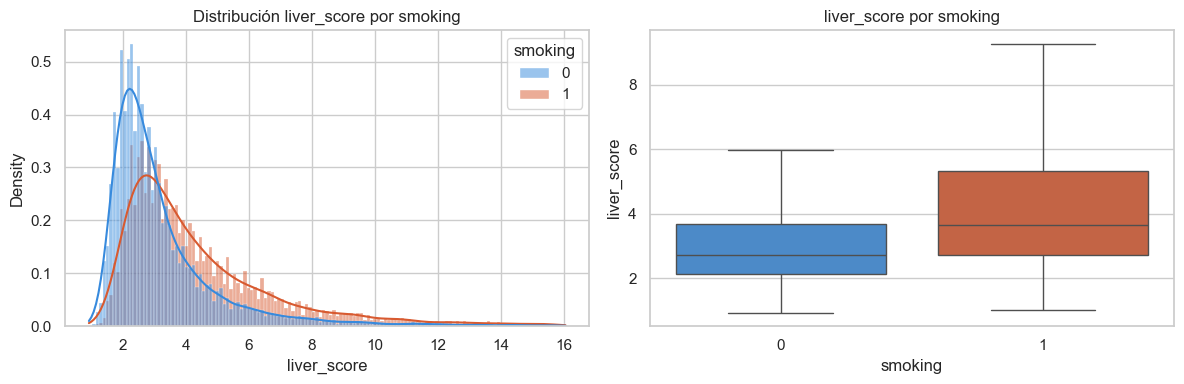

In [31]:
df['liver_score'] = df['gtp'] + df['ast'] + df['alt']
print(df.groupby('smoking')['liver_score'].agg(['mean','median']).round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Cap al p99 solo para visualización
cap = df['liver_score'].quantile(0.99)
df_tmp = df[df['liver_score'] <= cap]
sns.histplot(data=df_tmp, x='liver_score', hue='smoking', palette=PAL,
             kde=True, stat='density', common_norm=False, ax=axes[0])
axes[0].set_title('Distribución liver_score por smoking')
sns.boxplot(data=df_tmp, x='smoking', y='liver_score', hue='smoking', palette=PAL, showfliers=False, legend=False, ax=axes[1])
axes[1].set_title('liver_score por smoking')
plt.tight_layout()
plt.show()


liver_score (gtp + ast + alt) muestra una separación clara entre clases — los fumadores presentan valores consistentemente más altos, con mayor dispersión. Esto valida la decisión de crear esta feature combinada en lugar de usar las tres enzimas por separado, ya que resume el daño hepático asociado al tabaquismo en un único indicador con buen poder discriminativo.

### 4.2 Ratio lipídico: Triglicéridos / HDL

`lipid_ratio = triglyceride / hdl`

Indicador clásico de riesgo cardiovascular. El tabaco sube triglicéridos y baja HDL, 
por lo que este ratio debería separar mejor las clases que cada variable sola.

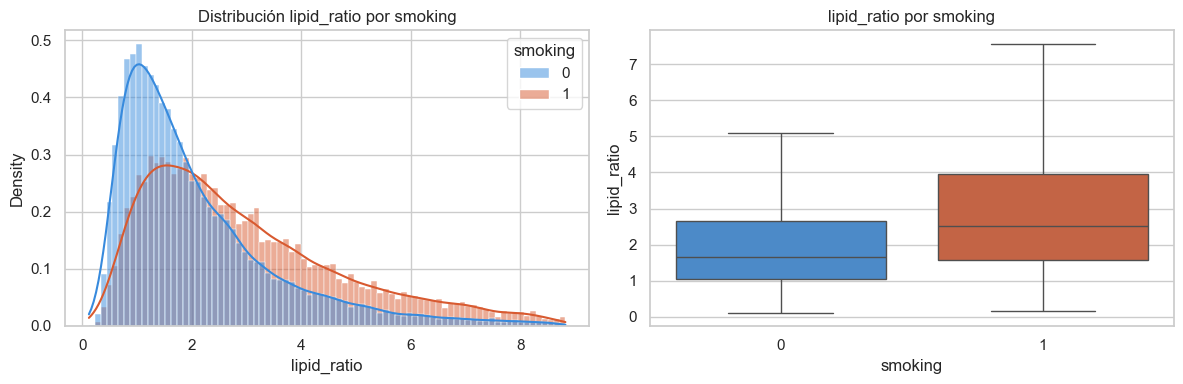

In [32]:
df['lipid_ratio'] = df['triglyceride'] / df['hdl'].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cap = df['lipid_ratio'].quantile(0.99)
df_tmp = df[df['lipid_ratio'] <= cap]
sns.histplot(data=df_tmp, x='lipid_ratio', hue='smoking', palette=PAL,
             kde=True, stat='density', common_norm=False, ax=axes[0])
axes[0].set_title('Distribución lipid_ratio por smoking')
sns.boxplot(data=df_tmp, x='smoking', y='lipid_ratio', hue='smoking', palette=PAL, showfliers=False, legend=False, ax=axes[1])
axes[1].set_title('lipid_ratio por smoking')
plt.tight_layout()
plt.show()


lipid_ratio (triglicéridos / HDL) muestra una separación clara ,los fumadores tienen valores más altos y una distribución mucho más dispersa. Esto confirma la hipótesis del EDA: el tabaco sube triglicéridos y baja HDL simultáneamente, y su ratio captura ese efecto combinado mejor que cada variable por separado. Es una feature con buen poder discriminativo para el modelo.

### 4.3 Interacción género × hemoglobina

Dado que género es el predictor más fuerte y hemoglobina el segundo,
su interacción puede capturar el efecto diferencial del tabaco en hemoglobina según sexo.

In [33]:
df['gender_x_hemoglobin'] = df['gender'] * df['hemoglobin']
print(df.groupby('smoking')['gender_x_hemoglobin'].describe().round(3))


           count   mean    std  min   25%   50%   75%   max
smoking                                                    
0        31671.0  0.281  0.313  0.0  0.00  0.00  0.63  0.80
1        18329.0  0.606  0.135  0.0  0.59  0.63  0.67  0.88


La tabla muestra que `gender_x_hemoglobin` separa muy bien:

- **No fumadores:** media 0.28, con muchos valores en 0 (las mujeres, porque gender=0 anula la multiplicación)
- **Fumadores:** media 0.61, concentrados entre 0.59 y 0.67

La mediana de fumadores (0.63) casi triplica la de no fumadores (0.00) — es la feature con separación más limpia de todas las que creaste, lo cual tiene sentido porque combina los dos predictores más fuertes del dataset.

El único detalle a tener en cuenta es que esta feature básicamente está diciendo "es hombre con hemoglobina alta" — captura casi todo el efecto de género. En el modelo puede generar algo de redundancia con `gender` y `hemoglobin` por separado, pero dado que RF y XGBoost manejan bien la multicolinealidad, no es un problema real.

## 5. Correlación de nuevas features con el target

gender_x_hemoglobin    0.513
lipid_ratio            0.249
liver_score            0.196
Name: smoking, dtype: float64


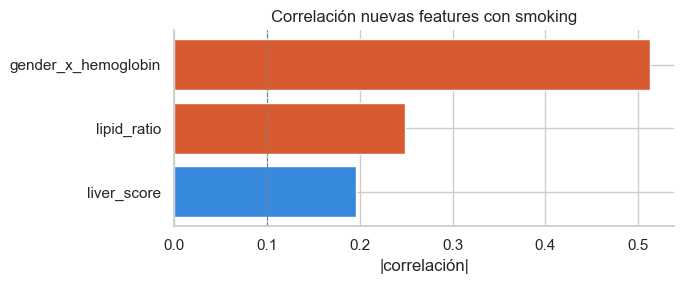

In [34]:
nuevas = ['liver_score', 'lipid_ratio', 'gender_x_hemoglobin']
corr_nuevas = df[nuevas + ['smoking']].corr()['smoking'].drop('smoking').abs().sort_values(ascending=False).round(3)
print(corr_nuevas)

fig, ax = plt.subplots(figsize=(7, 3))
colors = ['#D85A30' if v > 0.2 else '#378ADD' if v > 0.1 else '#AAAAAA' for v in corr_nuevas.values]
ax.barh(corr_nuevas.index[::-1], corr_nuevas.values[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0.1, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Correlación nuevas features con smoking')
ax.set_xlabel('|correlación|')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


weight_kg la eliminamos por dos razones:

Redundancia con waist_cm — correlación de 0.82 entre ambas. waist_cm aporta la misma información de masa corporal pero además tiene correlación directa con smoking (0.22) levemente superior.


Redundancia conceptual — el peso sin la altura no dice mucho por sí solo. Lo ideal era usarlo para calcular bmi (peso/altura²), pero bmi no mostró separación entre clases así que tampoco vale la pena mantener el peso como proxy.

En resumen: la información que aportaba weight_kg ya está capturada por waist_cm, y su versión más informativa (bmi) no fue útil para el modelo.

ast y alt — las eliminamos porque están resumidas en liver_score (gtp + ast + alt). Mantenerlas sería información duplicada y además liver_score demostró mejor separación que cada enzima por separado.


cholesterol — correlación de 0.74 con ldl y prácticamente cero con smoking. Además lipid_ratio ya captura el perfil lipídico de forma más informativa. No aporta nada que no esté en otras features.

In [35]:
features = [
    'gender', 'age', 'waist_cm', 
    'systolic', 'relaxation',
    'triglyceride', 'hdl',
    'hemoglobin', 'serum_creatinine', 
    'gtp', 'dental_caries',
    'liver_score', 'lipid_ratio', 'gender_x_hemoglobin'
]

In [36]:
df = df.drop(columns=[
    'height_cm', 'weight_kg',          # resumidas en bmi (descartado)
    'ast', 'alt',                       # resumidas en liver_score
    'cholesterol',                      # redundante con lipid_ratio, sin señal
    'ldl',                              # redundante con lipid_ratio
    'eyesight_left', 'eyesight_right',  # sin señal
    'hearing_left', 'hearing_right',    # sin señal
    'urine_protein',                    # sin señal
    'fasting_blood_sugar',              # sin señal
    'tartar',                           # sin señal
], errors='ignore')

In [37]:
df.columns

Index(['gender', 'age', 'waist_cm', 'systolic', 'relaxation', 'triglyceride',
       'hdl', 'hemoglobin', 'serum_creatinine', 'gtp', 'dental_caries',
       'smoking', 'liver_score', 'lipid_ratio', 'gender_x_hemoglobin'],
      dtype='object')

**Selección de variables — Justificación**

A partir del análisis de correlación realizado en el EDA y la inspección visual de las distribuciones por clase, se eliminaron las siguientes variables antes del modelado:

- **`height_cm` y `weight_kg`** — utilizadas para construir `bmi` pero descartadas una vez creada la feature. Además `weight_kg` presenta alta colinealidad con `waist_cm` (r=0.82).
- **`ast` y `alt`** — absorbidas por `liver_score` (gtp + ast + alt), que demostró mejor poder discriminativo que cada enzima por separado.
- **`cholesterol` y `ldl`** — alta colinealidad entre sí (r=0.74) y correlación prácticamente nula con el target. El perfil lipídico queda mejor representado por `lipid_ratio` (triglicéridos/HDL).
- **`eyesight_left`, `eyesight_right`, `hearing_left`, `hearing_right`, `urine_protein`, `fasting_blood_sugar`** — correlación absoluta con smoking inferior a 0.10 y sin separación visual entre clases en el EDA. No aportan señal predictiva relevante.
- **`tartar`** — correlación baja (~0.09) y distribución similar entre fumadores y no fumadores dentro de cada categoría.

El dataset final para modelado quedó con **14 features**, priorizando variables con correlación > 0.10 con el target y eliminando redundancias para reducir ruido y multicolinealidad.

In [38]:
df.head(5)

,gender,age,waist_cm,systolic,relaxation,triglyceride,hdl,hemoglobin,serum_creatinine,gtp,dental_caries,smoking,liver_score,lipid_ratio,gender_x_hemoglobin
0,0,40,3.38,4.75,3.04,3.42,3.04,0.51,0.00,1.13,0,0,2.67,1.125000,0.00
1,0,40,3.38,4.96,2.92,4.79,1.75,0.50,0.00,0.75,0,0,2.46,2.737143,0.00
2,1,55,3.33,5.75,3.58,7.58,2.29,0.63,0.04,0.92,0,1,2.47,3.310044,0.63
3,1,40,3.67,4.17,2.50,10.58,1.88,0.59,0.04,0.75,0,0,2.62,5.627660,0.59
4,0,40,3.58,5.00,3.08,3.08,2.58,0.50,0.00,0.92,0,0,2.17,1.193798,0.00


In [39]:

def outlier_detection(df, n, columns):
    rows = []
    will_drop_train = []
    for col in columns:
        Q1 = np.nanpercentile(df[col], 25)
        Q3 = np.nanpercentile(df[col], 75)
        IQR = Q3 - Q1
        outlier_point = 1.5 * IQR
        rows.extend(df[(df[col] < Q1 - outlier_point) | (df[col] > Q3 + outlier_point)].index)
    for r, c in Counter(rows).items():
        if c >= n: will_drop_train.append(r)
    return will_drop_train

will_drop = outlier_detection(df, 5, df.select_dtypes(["float", "int"]).columns)
print(f"Filas a eliminar: {len(will_drop)} de {len(df)} ({len(will_drop)/len(df)*100:.1f}%)")
df = df.drop(index=will_drop).reset_index(drop=True)
print(f"Shape tras limpieza de outliers: {df.shape}")

Filas a eliminar: 134 de 50000 (0.3%)
Shape tras limpieza de outliers: (49866, 15)


## 6. Scaling

Aplicamos **StandardScaler** sobre las variables numéricas.

In [40]:
# Solo age quedó en escala original
scaler_age = StandardScaler()

# 2. Aplicar el escalado
df_scaled = df.copy()
df_scaled['age'] = scaler_age.fit_transform(df_scaled[['age']])
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True) # Por si la carpeta no existe

scaler_path = os.path.join(MODELS_DIR, "scaler_age.joblib")
joblib.dump(scaler_age, scaler_path)

print(f"Escalador guardado exitosamente en: {scaler_path}")

Escalador guardado exitosamente en: c:\Users\Admin\ss\Smoking-Test\models\scaler_age.joblib


In [41]:
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True) # Por si la carpeta no existe

scaler_path = os.path.join(MODELS_DIR, "scaler_age.joblib")
joblib.dump(scaler_age, scaler_path)

print(f"Escalador guardado exitosamente en: {scaler_path}")

Escalador guardado exitosamente en: c:\Users\Admin\ss\Smoking-Test\models\scaler_age.joblib


In [42]:
df_scaled.head(5)

,gender,age,waist_cm,systolic,relaxation,triglyceride,hdl,hemoglobin,serum_creatinine,gtp,dental_caries,smoking,liver_score,lipid_ratio,gender_x_hemoglobin
0,0,-0.347134,3.38,4.75,3.04,3.42,3.04,0.51,0.00,1.13,0,0,2.67,1.125000,0.00
1,0,-0.347134,3.38,4.96,2.92,4.79,1.75,0.50,0.00,0.75,0,0,2.46,2.737143,0.00
2,1,0.893385,3.33,5.75,3.58,7.58,2.29,0.63,0.04,0.92,0,1,2.47,3.310044,0.63
3,1,-0.347134,3.67,4.17,2.50,10.58,1.88,0.59,0.04,0.75,0,0,2.62,5.627660,0.59
4,0,-0.347134,3.58,5.00,3.08,3.08,2.58,0.50,0.00,0.92,0,0,2.17,1.193798,0.00


## 7. Dataset final

In [45]:
print(f"Shape final: {df_scaled.shape}")
print(f"Features: {df_scaled.shape[1] - 1}")
print(f"Target balance:\n{df_scaled['smoking'].value_counts(normalize=True).round(3)}")
df_scaled.head()

Shape final: (49866, 15)
Features: 14
Target balance:
smoking
0    0.634
1    0.366
Name: proportion, dtype: float64


,gender,age,waist_cm,systolic,relaxation,triglyceride,hdl,hemoglobin,serum_creatinine,gtp,dental_caries,smoking,liver_score,lipid_ratio,gender_x_hemoglobin
0,0,-0.347134,3.38,4.75,3.04,3.42,3.04,0.51,0.00,1.13,0,0,2.67,1.125000,0.00
1,0,-0.347134,3.38,4.96,2.92,4.79,1.75,0.50,0.00,0.75,0,0,2.46,2.737143,0.00
2,1,0.893385,3.33,5.75,3.58,7.58,2.29,0.63,0.04,0.92,0,1,2.47,3.310044,0.63
3,1,-0.347134,3.67,4.17,2.50,10.58,1.88,0.59,0.04,0.75,0,0,2.62,5.627660,0.59
4,0,-0.347134,3.58,5.00,3.08,3.08,2.58,0.50,0.00,0.92,0,0,2.17,1.193798,0.00


In [46]:
df_scaled.to_csv(DATA_PATH, index=False)
